# Bluesky Data Science
## Part 02 - Searching and Snowballing: Building a Post Archive

June 2026
Copyright and distributed under an [MIT License](https://opensource.org/licenses/MIT)

*An [R Markdown counterpart](../../RMarkdown/Part%2002%20-%20Searching%20and%20Snowballing/Part%2002%20-%20Searching%20and%20Snowballing.Rmd) of this notebook, using the [bskyr](https://christophertkenny.com/bskyr/) package, lives in the parallel `RMarkdown/` directory.*


## Background

> **tl;dr**: This notebook starts from a *topic* rather than an *account*: it teaches Bluesky's post search endpoint, dissects how posts store mentions, hashtags, and links in "facets", and then uses those facets to snowball outward from a seed account into a deduplicated, documented, and reusable archive of posts.

[Part 00](../Part%2000%20-%20Introduction.ipynb) introduced the ATProto client and its basic endpoints, and Part 01 developed the machinery for collecting data at scale: cursors, rate limits, and ethics. Both were *account-centric* — you knew whose data you wanted before you started. Most research projects do not start that way. They start with a topic ("the wildfire evacuation", "the platform migration", "#AcademicSky") and a question, and the first methodological problem is constructing a **sampling frame** — the concrete list of units (for us, posts) from which a sample is actually drawn. Which posts are "about" the topic, and how do you defend the boundary you drew? Survey researchers agonize over sampling frames (a phone book misses everyone without a phone); social media researchers should too (a keyword query misses everyone who never used your keyword).

On Twitter, a generation of researchers answered this with hashtag search — collect everything tagged #egypt or #ausvotes and call it the conversation (Bruns & Burgess 2011). That strategy is fast and transparent, but it samples only the most performative, self-labeling slice of a conversation (Tufekci 2014; Olteanu et al. 2019 is a comprehensive and readable tour of these pitfalls — both are linked in the References). In this notebook we develop two complementary strategies and combine them:

1. **Search.** Bluesky's [`searchPosts`](https://docs.bsky.app/docs/api/app-bsky-feed-search-posts) endpoint supports keyword and hashtag queries with date, language, and author filters. (It requires authentication, so the cells that call it are guarded and skip themselves gracefully on the public AppView.)
2. **Snowballing.** Starting from one or more *seed* accounts or posts, follow the traces inside posts themselves — the accounts they mention, the posts they reply to, the hashtags they use ([facets](https://docs.bsky.app/docs/advanced-guides/post-richtext), explained in Section 2) — outward in *waves*, collecting as you go. This works entirely on public, unauthenticated endpoints.

By the end we will have a tidy post archive saved to disk, with metadata documenting exactly how it was built, that later notebooks (Parts 03–06) can reload without touching the network.

Three documentation sites are worth bookmarking now, because we link to them throughout: [docs.bsky.app](https://docs.bsky.app) (the Bluesky HTTP API reference), [atproto.com](https://atproto.com) (the underlying AT Protocol specifications), and [atproto.blue](https://atproto.blue) (the Python `atproto` SDK we call from every cell).

### Learning objectives

1. Query `app.bsky.feed.searchPosts` with `q`, `since`/`until`, `lang`, and `sort` parameters and paginate it with cursors
2. Dissect a post record's internals: rich-text `facets` (mentions, links, hashtags with byte offsets), `langs`, replies, and embeds
3. Write and reuse facet-extraction helpers from a companion module, `snowball.py`
4. Design and run a **snowball sample**: seeds, waves, edge definitions, and caps
5. Compute **saturation diagnostics** that tell you what each additional wave is buying you
6. Persist a deduplicated archive to Parquet with a metadata file that makes the sampling frame reproducible, then reload and re-hydrate it

## Setup

We begin with the same common libraries as the earlier parts. A quick tour of why each one is here:

* [`json`](https://docs.python.org/3/library/json.html) — the wire format APIs speak; we also use it at the end to save our collection metadata as a human-readable file.
* [`time`](https://docs.python.org/3/library/time.html) and [`datetime`](https://docs.python.org/3/library/datetime.html) — `time.sleep` keeps us polite between paginated API requests, and timezone-aware `datetime` objects build search windows and timestamp the collection.
* [`collections.Counter`](https://docs.python.org/3/library/collections.html#collections.Counter) — a dictionary specialized for tallying, which we use to rank the accounts and hashtags our crawl encounters.
* [pandas](https://pandas.pydata.org/docs/) (and [NumPy](https://numpy.org/doc/stable/) underneath it) — the DataFrame that holds our tidy post archive.
* [Matplotlib](https://matplotlib.org/stable/) — plots; the `%matplotlib inline` magic renders figures directly in the notebook.

In [1]:
# APIs speak JSON
import json

# Politeness between requests, timestamps for metadata
import time
from datetime import datetime, timedelta, timezone

# Tallying mentions and hashtags
from collections import Counter

# DataFrames
import pandas as pd
import numpy as np

# Data visualization
%matplotlib inline
import matplotlib.pyplot as plt

With the libraries loaded, we connect, as in Part 01, through the `get_client()` helper in `bsky_client.py`, which lives in this notebook's directory. It wraps the [atproto Python SDK](https://atproto.blue): if you saved an `atproto.json` credentials file (see Part 00), you get an authenticated client; if not, you get a read-only client pointed at the public **AppView** (`https://public.api.bsky.app`) — the server that aggregates the network's public data and serves most *read* endpoints without any login.

The cell ends with `is_authenticated(client)`, which returns `True` or `False`, so the executed notebook records which mode this run used. Everything in this notebook *except* the search cells works either way, and the search cells check `is_authenticated(client)` and explain themselves when skipped.

In [2]:
from bsky_client import get_client, is_authenticated

client = get_client()

is_authenticated(client)

No atproto.json found: using the unauthenticated public AppView.
Read endpoints work; search and write endpoints require logging in.


False

## 1. Searching for posts

The search endpoint is `app.bsky.feed.search_posts` (XRPC: [`app.bsky.feed.searchPosts`](https://docs.bsky.app/docs/api/app-bsky-feed-search-posts)). Unlike the feed and graph endpoints we have used so far, it queries a **search index** maintained by the AppView, and the public AppView refuses it without authentication (HTTP `403 Forbidden`). That is why the cells in this section are wrapped in `if is_authenticated(client):` guards.

Two recurring terms, introduced in Part 01 and used heavily here: an **endpoint** is one named operation the API exposes (defined by a schema the protocol calls a [lexicon](https://atproto.com/guides/lexicon)), and a **cursor** is an opaque bookmark string the server hands back with each page of results — pass it into the next request to get the next page, and stop when it stops coming back. Every collection loop in this notebook is a cursor loop.

The parameters worth knowing:

| Parameter | What it does |
|---|---|
| `q` | The query string. Supports quoted phrases (`"data science"`), hashtags (`#openscience`), and `from:handle` to scope to an author |
| `since` / `until` | Restrict by post creation time, as ISO 8601 datetimes (e.g. `2026-06-01T00:00:00Z`) |
| `lang` | Restrict to posts self-declaring a language (e.g. `en`) |
| `sort` | `latest` (reverse chronological) or `top` (relevance/engagement) |
| `author`, `mentions`, `tag`, `domain`, `url` | Scope to an author, mentioned account, hashtag, or linked site |
| `limit` / `cursor` | Page size (max 100) and the pagination cursor from Part 01 |

One epistemological caution before we use it: a search index is **not the network's history**. Deleted posts, deactivated accounts, and accounts that opt out of indexing are missing, so a corpus built from search inherits survivorship bias relative to collecting in real time (the same gap Morstatter et al. 2013 documented between Twitter's Streaming API and its firehose). Record *when* you searched alongside *what* you searched.

In [3]:
if is_authenticated(client):
    response = client.app.bsky.feed.search_posts(params={'q': '"snowball sampling"', 'limit': 5})
    print(f"Index reports about {response.hits_total} matching posts\n")
    for post in response.posts:
        print(f"@{post.author.handle} at {post.record.created_at}")
        print(f"   {post.record.text[:120]!r}\n")
else:
    print("Skipping: searchPosts requires authentication, and this client is using")
    print("the public AppView, which returns 403 Forbidden for search requests.")
    print("Save an atproto.json credentials file (see Part 00) to run this cell.")
    print("Sections 2 onward use only public endpoints and run for everyone.")

Skipping: searchPosts requires authentication, and this client is using
the public AppView, which returns 403 Forbidden for search requests.
Save an atproto.json credentials file (see Part 00) to run this cell.
Sections 2 onward use only public endpoints and run for everyone.


If you ran that cell authenticated, you saw the index's estimated total — `hits_total` is an *estimate*, useful as an order of magnitude but not an exact census — followed by the five most relevant matches, each with the author's handle, timestamp, and the first 120 characters of text. If you ran it unauthenticated, you saw the skip message instead. Either outcome is fine: everything from Section 2 onward uses only public endpoints and runs for everyone.

### Paginating a search

A single response returns at most 100 posts. To collect everything matching a query within a time window, we reuse the cursor loop pattern from Part 01: pass the previous response's `cursor` back in, stop when it comes back empty, and sleep briefly between requests. Defining the function is harmless without authentication — only *calling* it needs to be guarded.

In [4]:
def search_posts_paged(client, query, max_posts=500, pause=0.1, **filters):
    """Collect up to max_posts results for a searchPosts query.

    Extra keyword arguments (since, until, lang, sort, author, tag, ...)
    are passed through to the endpoint as filters. Requires an
    authenticated client.
    """
    posts, cursor = [], None
    while len(posts) < max_posts:
        params = {'q': query, 'limit': 100, 'cursor': cursor, **filters}
        response = client.app.bsky.feed.search_posts(params=params)
        posts.extend(response.posts)
        cursor = response.cursor
        if cursor is None or len(response.posts) == 0:
            break
        time.sleep(pause)
    return posts[:max_posts]

Now we put the paginated function to work on a realistic query: the last seven days of English-language posts tagged `#openscience`, newest first. The `since`/`until` filters take [ISO 8601](https://en.wikipedia.org/wiki/ISO_8601) datetimes (the `2026-06-01T00:00:00Z` shape, where the trailing `Z` means UTC); we build the window with [`timedelta`](https://docs.python.org/3/library/datetime.html#datetime.timedelta) and format it with [`strftime`](https://docs.python.org/3/library/datetime.html#strftime-and-strptime-behavior). Capping at `max_posts=300` keeps this demonstration polite — raise the cap for a real collection.

In [5]:
if is_authenticated(client):
    # Last seven days of English-language posts tagged #openscience
    until = datetime.now(timezone.utc)
    since = until - timedelta(days=7)

    results = search_posts_paged(
        client,
        '#openscience',
        max_posts=300,
        since=since.strftime('%Y-%m-%dT%H:%M:%SZ'),
        until=until.strftime('%Y-%m-%dT%H:%M:%SZ'),
        lang='en',
        sort='latest',
    )
    print(f"Collected {len(results)} posts from "
          f"{len(set(p.author.did for p in results))} accounts")
else:
    print("Skipping: searchPosts requires authentication (403 on the public AppView).")
    print("The snowball collection in Section 4 builds a topical archive without")
    print("search, using only public endpoints — that is our fallback strategy here.")

Skipping: searchPosts requires authentication (403 on the public AppView).
The snowball collection in Section 4 builds a topical archive without
search, using only public endpoints — that is our fallback strategy here.


### When you cannot search

If you are running unauthenticated, the guarded cells above printed an explanation and moved on. That is not just a limitation of this tutorial — it is a realistic research situation. Search indexes change, access tiers appear and disappear (ask any Twitter researcher), and queries silently miss posts that never used your keywords. A robust collection strategy follows the *traces inside the posts themselves*, which on Bluesky are fully public.

So before we can snowball, we need to understand what a post record actually contains.

## 2. The anatomy of a post record

Endpoints like `get_author_feed`, [`get_posts`](https://docs.bsky.app/docs/api/app-bsky-feed-get-posts), and `search_posts` return hydrated **post views** (`app.bsky.feed.defs#postView`). Two layers matter:

* The **record** (`post.record`) is what the author's repository actually stores: the text, creation time, language tags, reply references, facets, and embeds. This is the durable, author-controlled part.
* The **view** wraps the record with AppView-computed context: the author's profile, like/repost/reply counts, and hydrated embeds. This part changes every time you fetch.

Every post is identified by two values you will see everywhere in AT Protocol data:

* Its **URI** is the post's address, written in the [`at://` scheme](https://atproto.com/specs/at-uri-scheme): `at://<DID>/<collection>/<record key>`. The **DID** ([decentralized identifier](https://atproto.com/specs/did), e.g. `did:plc:lse7...`) is the account's permanent machine ID — unlike a handle, it never changes even if the user renames themselves, which is why researchers should key datasets on DIDs. The collection (`app.bsky.feed.post`) says what kind of record this is, and the [record key](https://atproto.com/specs/record-key) is a short timestamp-flavored ID for this particular post.
* Its **CID** (content identifier) is a cryptographic fingerprint (hash) of the record's content. Where the URI says "the post at this address", the CID says "exactly this version of it"; together they form a *strong reference* that cannot be silently swapped for different content.

To dissect one post, we use `get_posts`, which re-hydrates up to 25 posts by their `at://` URIs — the same endpoint you will use later to refresh an archive. We pinned a post from our seed account that conveniently contains a mention, a hashtag, *and* a link. Because live posts can be deleted at any time, the cell falls back to scanning the seed's recent feed for another richly faceted post if the pinned one has vanished.

In [6]:
EXAMPLE_URI = 'at://did:plc:lse7quaysss2d3xxm76mouhd/app.bsky.feed.post/3mllcrm65wk25'

found = client.get_posts(uris=[EXAMPLE_URI]).posts

if not found:  # the pinned example was deleted — pick a replacement with rich facets
    print('Pinned example post is gone; selecting a recent faceted post instead.\n')
    feed = client.get_author_feed(actor='nytimes.com', limit=100).feed
    candidates = [item.post for item in feed
                  if item.reason is None and item.post.record.facets]

    def n_feature_types(post):
        """How many distinct facet feature types (mention/tag/link) a post uses."""
        return len({feature.py_type
                    for facet in post.record.facets
                    for feature in facet.features})

    found = [max(candidates, key=n_feature_types)]

example_post = found[0]

print(example_post.uri, '\n')
print(example_post.record.text)

at://did:plc:lse7quaysss2d3xxm76mouhd/app.bsky.feed.post/3mllcrm65wk25 

I have a column in @boulderrl.bsky.social about the implications of the "tipped wage offset" and its implications for deteriorating housing affordability in #boulder boulderreportinglab.org/2026/05/10/b...


### Facets

Notice that the text above is plain — no markup around `@boulderrl.bsky.social` or `#boulder`. Bluesky does not parse rich text out of the string when displaying a post. Instead, the record carries a list of **facets** ([`app.bsky.richtext.facet`](https://docs.bsky.app/docs/advanced-guides/post-richtext)), each pairing a *byte range* of the text with one or more *features*:

* `#mention` — an @-mention, carrying the mentioned account's stable `did`
* `#link` — an external link, carrying the full `uri` (the visible text is often truncated)
* `#tag` — a hashtag, carrying the `tag` without the `#`

This is wonderful for researchers: mentions arrive pre-resolved to DIDs (no fragile handle parsing), and links arrive un-shortened.

In the next cell we dump each facet to a plain dictionary with `.model_dump()` — the SDK's response objects are [pydantic](https://docs.pydantic.dev/latest/) models, and `model_dump()` converts them into ordinary Python dicts that are easy to read.

In [7]:
[facet.model_dump() for facet in example_post.record.facets]

[{'features': [{'did': 'did:plc:7lqpdof4fqal4imvharp66vb',
    'py_type': 'app.bsky.richtext.facet#mention'}],
  'index': {'byte_end': 41,
   'byte_start': 19,
   'py_type': 'app.bsky.richtext.facet#byteSlice'},
  'py_type': 'app.bsky.richtext.facet'},
 {'features': [{'tag': 'boulder', 'py_type': 'app.bsky.richtext.facet#tag'}],
  'index': {'byte_end': 165,
   'byte_start': 157,
   'py_type': 'app.bsky.richtext.facet#byteSlice'},
  'py_type': 'app.bsky.richtext.facet'},
 {'features': [{'uri': 'https://boulderreportinglab.org/2026/05/10/brian-keegan-boulders-tipped-wage-debate-rests-on-a-myth-about-what-restaurant-workers-earn/',
    'py_type': 'app.bsky.richtext.facet#link'}],
  'index': {'byte_end': 205,
   'byte_start': 166,
   'py_type': 'app.bsky.richtext.facet#byteSlice'},
  'py_type': 'app.bsky.richtext.facet'}]

The `index` on each facet is a `byteSlice`: `byte_start` and `byte_end` are offsets into the **UTF-8 encoded bytes** of the text, *not* character positions. The distinction matters the moment a post contains an emoji or non-Latin script, where one character can occupy several bytes. To recover the highlighted span, encode the text first, slice the bytes, then decode.

In [8]:
text_bytes = example_post.record.text.encode('utf-8')

for facet in example_post.record.facets:
    span = text_bytes[facet.index.byte_start:facet.index.byte_end].decode('utf-8')
    for feature in facet.features:
        kind = feature.py_type.split('#')[-1]
        target = getattr(feature, 'did', None) or getattr(feature, 'tag', None) or getattr(feature, 'uri', None)
        print(f"{kind:>8}: {span!r}")
        print(f"          -> {target}")

 mention: '@boulderrl.bsky.social'
          -> did:plc:7lqpdof4fqal4imvharp66vb
     tag: '#boulder'
          -> boulder
    link: 'boulderreportinglab.org/2026/05/10/b...'
          -> https://boulderreportinglab.org/2026/05/10/brian-keegan-boulders-tipped-wage-debate-rests-on-a-myth-about-what-restaurant-workers-earn/


Each line above pairs a highlighted span of the visible text with the machine-readable target stored behind it: the mention resolves to a stable `did:plc:...` identifier, the hashtag to its bare tag, and the link to the full URL even when the visible text was shortened for display. This is exactly the structure our extraction helpers in the next section rely on — no regular expressions, no guessing.

### Languages, replies, and embeds

Three more record fields we will use when building the archive:

* **`langs`** — a list of self-declared language codes. These are set by the posting client (often auto-detected, sometimes wrong), so treat them as a useful filter, not ground truth.
* **`reply`** — present when the post is a reply, containing **strong references** (URI + CID pairs, as defined above — the address plus the content fingerprint) to the *parent* post (the post being answered) and the thread *root* (the post that started the whole thread). The parent's author DID is embedded right inside the `at://` URI, which we will exploit for snowballing.
* **`embed`** — attached media: images, video, an external link card, or a quoted post. The record stores the author's intent (`app.bsky.embed.external`), while the view carries the hydrated version (`...#view`) with resolved thumbnails. Part 07 is devoted to these.

In [9]:
print('langs:        ', example_post.record.langs)
print('reply:        ', example_post.record.reply)
print('record embed: ', None if example_post.record.embed is None else example_post.record.embed.py_type)
print('view embed:   ', None if example_post.embed is None else example_post.embed.py_type)
print('likes/reposts:', example_post.like_count, '/', example_post.repost_count)

langs:         ['en']
reply:         None
record embed:  app.bsky.embed.external
view embed:    app.bsky.embed.external#view
likes/reposts: 6 / 4


## 3. Facet helpers in `snowball.py`

Pulling features out of nested facet lists is exactly the kind of fiddly code that should be written once, tested, and imported — not pasted between notebook cells. This part ships with a companion module, [`snowball.py`](snowball.py), that packages what we just learned:

| Function | Returns |
|---|---|
| `extract_mentions(post)` | DIDs @-mentioned in the post |
| `extract_tags(post)` | hashtags, lowercased |
| `extract_links(post)` | external link URLs |
| `extract_reply_parent(post)` | DID of the account the post replies to, or `None` |
| `fetch_author_posts(client, actor, ...)` | an account's recent original posts, paginated politely |
| `count_engaged_accounts(posts, ...)` | a `Counter` of accounts mentioned or replied to |
| `post_to_row(post, wave)` | a flat dict for building a tidy DataFrame |

Open the file — it is short, and every function operates on the same hydrated post views we have been handling (see the [atproto SDK documentation](https://atproto.blue) for the client API these helpers build on). The cell below imports the helpers and re-runs them on our example post so you can match each output to the facets we just dissected by hand.

In [10]:
from snowball import (
    extract_mentions,
    extract_tags,
    extract_links,
    extract_reply_parent,
    fetch_author_posts,
    count_engaged_accounts,
    post_to_row,
)

print('mentions:', extract_mentions(example_post))
print('hashtags:', extract_tags(example_post))
print('links:   ', extract_links(example_post))
print('reply to:', extract_reply_parent(example_post))

mentions: ['did:plc:7lqpdof4fqal4imvharp66vb']
hashtags: ['boulder']
links:    ['https://boulderreportinglab.org/2026/05/10/brian-keegan-boulders-tipped-wage-debate-rests-on-a-myth-about-what-restaurant-workers-earn/']
reply to: None


## 4. Snowball sampling: from one seed to a corpus

**Snowball sampling** (Goodman 1961) is a chain-referral design: start from a small set of **seeds** (the units you pick by hand), follow their referrals to recruit a first **wave**, follow the first wave's referrals to a second wave, and so on — each *wave* is one round of collection, one hop further from the seeds — until you hit saturation or a budget. Survey researchers use it for hard-to-reach populations; for us, the "referrals" are the traces inside posts, and the design builds a topical-or-relational corpus without needing search at all.

Our edge definition needs one platform-specific adjustment. On Twitter, replying *inserted* an @-mention into the text, so mentions captured conversation. On Bluesky, replies are threaded by the `reply` reference and contain **no** @-mention, so facets alone badly undercount who an account talks to. `count_engaged_accounts` therefore counts an account as *engaged* by a post if the post **@-mentions it or replies to it** — each post counting an account at most once.

The design, which we record explicitly because every one of these choices shapes the sample:

* **Seed:** `nytimes.com` (The New York Times — a large institutional account whose engagement traces lead to its journalists and sister accounts)
* **Wave 0:** the seed's ~200 most recent original posts (reposts skipped — their text belongs to other authors)
* **Wave 1:** the ~100 most recent posts from each of the **8** accounts wave 0 engaged most often
* **Wave 2:** the same for the most-engaged *new* accounts found in wave 1, capping the whole crawl at **15** accounts
* **Politeness:** 100 posts per request, `time.sleep(0.1)` between requests, a page cap per account
* **Deduplication:** by post `uri`, keeping the earliest wave that found a post

The next cell freezes every one of these parameters as a named constant and timestamps the collection — values we will write into the archive's metadata file at the end, so the sampling frame stays auditable.

In [11]:
SEED_ACTOR = 'nytimes.com'
WAVE0_MAX_POSTS = 200     # posts to collect from the seed
WAVE1_ACCOUNTS = 8        # most-engaged accounts to crawl in wave 1
POSTS_PER_ACCOUNT = 100   # posts to collect per snowballed account
MAX_TOTAL_ACCOUNTS = 15   # hard cap on accounts crawled across all waves
PAUSE = 0.1               # seconds between paginated requests

COLLECTED_AT = datetime.now(timezone.utc).isoformat(timespec='seconds')
print('Collection started at', COLLECTED_AT)

Collection started at 2026-06-10T16:21:46+00:00


### Wave 0: the seed account

`fetch_author_posts` pages through [`get_author_feed`](https://docs.bsky.app/docs/api/app-bsky-feed-get-author-feed) with a cursor loop until it has the requested number of original posts (or runs out of pages), skipping reposts — a repost's text belongs to a different author, so keeping it would smuggle other accounts' words into the seed's wave. We also record the seed's DID from the first returned post, because the rest of the pipeline works with DIDs rather than handles.

In [12]:
wave0 = fetch_author_posts(client, SEED_ACTOR, max_posts=WAVE0_MAX_POSTS, pause=PAUSE)

seed_did = wave0[0].author.did
created = sorted(post.record.created_at for post in wave0)

print(f"Wave 0: {len(wave0)} original posts by {SEED_ACTOR} ({seed_did})")
print(f"Spanning {created[0]} to {created[-1]}")

Wave 0: 200 original posts by nytimes.com (did:plc:eclio37ymobqex2ncko63h4r)
Spanning 2026-06-07T18:10:03.172575Z to 2026-06-10T16:20:06.449096Z


### Whom does the seed engage?

The printout above gives wave 0's size and its *time span*. The span is worth a second look: "the most recent 200 posts" covers a different calendar window for every account — days for a prolific poster, years for a quiet one — an activity bias we return to in Section 8.

Now we rank the accounts wave 0 mentions or replies to. These engaged accounts are the **frontier** — the candidates for wave 1. We exclude the seed itself (self-threads would otherwise dominate) and resolve the top DIDs to handles with `get_profiles` so the table is human-readable.

In [13]:
engaged_0 = count_engaged_accounts(wave0, exclude={seed_did})
print(f"Wave 0 engaged {len(engaged_0)} distinct accounts\n")

wave1_dids = [did for did, n in engaged_0.most_common(WAVE1_ACCOUNTS)]

profiles = client.get_profiles(actors=wave1_dids).profiles
handle_of = {p.did: p.handle for p in profiles}

pd.DataFrame(
    [{'handle': handle_of.get(did, '?'), 'did': did, 'posts_engaging': engaged_0[did]}
     for did in wave1_dids]
)

Wave 0 engaged 4 distinct accounts



,handle,did,posts_engaging
0,theathletic.com,did:plc:b2kutgxqlltwc6lhs724cfwr,14
1,nytopinion.nytimes.com,did:plc:yllqcfu4oy424rlfpnzj32ka,13
2,theathleticfc.bsky.social,did:plc:fa7xejyd32fvuar5hpa2n2yi,9
3,thomaslfriedman.bsky.social,did:plc:itzjvkn3qzkx7lonrgh2zm5a,1


Read this table as the seed's conversational inner circle: `posts_engaging` counts how many of the seed's posts mentioned or replied to each account, with each post counting an account at most once. Notice what ranking by engagement *does* to the sample: it recruits the accounts the seed interacts with most often, not a random draw from everyone the seed knows. That pair of choices — the **edge definition** (mention-or-reply) plus the ranking rule (most engaged first) — is the heart of any snowball design, and small changes to either produce noticeably different corpora.

### Wave 1: crawl the frontier

We fetch each frontier account's recent original posts. Real crawls hit real-world mess — deleted or deactivated accounts, feeds the SDK cannot parse — so the loop catches exceptions, reports them, and keeps going rather than dying mid-collection.

In [14]:
wave1 = []
crawled = {seed_did}

for did in wave1_dids:
    try:
        posts = fetch_author_posts(client, did, max_posts=POSTS_PER_ACCOUNT,
                                   max_pages=4, pause=PAUSE)
        print(f"  {handle_of.get(did, did):<28} {len(posts):>4} posts")
    except Exception as error:
        print(f"  ! {handle_of.get(did, did)}: {type(error).__name__}, skipping")
        posts = []
    crawled.add(did)
    wave1.extend(posts)
    time.sleep(PAUSE)

print(f"\nWave 1: {len(wave1)} posts from {len(wave1_dids)} accounts")

  theathletic.com               100 posts


  nytopinion.nytimes.com        100 posts


  theathleticfc.bsky.social     100 posts
  thomaslfriedman.bsky.social    88 posts



Wave 1: 388 posts from 4 accounts


### Wave 2: one more hop

Each wave's posts reveal new engaged accounts. We rank the accounts wave 1 engaged — excluding everyone already crawled — and take just enough to stay under our `MAX_TOTAL_ACCOUNTS` cap. This is where snowballs earn their name: left uncapped, the frontier grows explosively with every wave, so an explicit budget is part of the design, not an afterthought.

In [15]:
engaged_1 = count_engaged_accounts(wave1, exclude=crawled)
budget = MAX_TOTAL_ACCOUNTS - len(crawled)
wave2_dids = [did for did, n in engaged_1.most_common(budget)]

print(f"Wave 1 engaged {len(engaged_1)} new accounts; crawling the top {len(wave2_dids)}\n")

wave2 = []
for did in wave2_dids:
    try:
        posts = fetch_author_posts(client, did, max_posts=POSTS_PER_ACCOUNT,
                                   max_pages=4, pause=PAUSE)
        handle = posts[0].author.handle if posts else did
        print(f"  {handle:<28} {len(posts):>4} posts")
    except Exception as error:
        print(f"  ! {did}: {type(error).__name__}, skipping")
        posts = []
    crawled.add(did)
    wave2.extend(posts)
    time.sleep(PAUSE)

print(f"\nWave 2: {len(wave2)} posts. Total accounts crawled: {len(crawled)}")

Wave 1 engaged 30 new accounts; crawling the top 10



  david-ornstein.bsky.social    100 posts
  jamespearcelfc.bsky.social     58 posts


  polballus.bsky.social          52 posts


  adamcrafton.bsky.social       100 posts


  meganferinga.bsky.social      100 posts


  paultenorio.bsky.social       100 posts


  jameshorncastle.bsky.social    15 posts


  charpur.bsky.social           100 posts


  jacklang.bsky.social          100 posts


  henrybushnell.bsky.social     100 posts

Wave 2: 825 posts. Total accounts crawled: 15


## 5. Saturation diagnostics: when to stop

Snowball designs need a stopping rule, and the honest way to choose one is to measure what each wave *adds*. For every wave we count, in collection order:

* **new posts** — URIs not collected in any earlier wave
* **new accounts discovered** — authors, mentioned accounts, and reply parents not seen before
* **new hashtags discovered** — tags not seen before

When these marginal yields collapse toward zero, the snowball has **saturated** — more waves would mostly re-collect what you already have. When they keep growing, the frontier is still expanding and your boundary is a budget choice you must defend.

In [16]:
seen_uris, seen_accounts, seen_tags = set(), set(), set()
wave_posts = {0: wave0, 1: wave1, 2: wave2}
wave_stats = []

for wave, posts in wave_posts.items():
    new_posts = new_accounts = new_tags = 0
    for post in posts:
        if post.uri not in seen_uris:
            seen_uris.add(post.uri)
            new_posts += 1
        accounts = set(extract_mentions(post)) | {post.author.did}
        parent = extract_reply_parent(post)
        if parent:
            accounts.add(parent)
        for did in accounts:
            if did not in seen_accounts:
                seen_accounts.add(did)
                new_accounts += 1
        for tag in extract_tags(post):
            if tag not in seen_tags:
                seen_tags.add(tag)
                new_tags += 1
    wave_stats.append({'wave': wave, 'posts_collected': len(posts),
                       'new_posts': new_posts, 'new_accounts': new_accounts,
                       'new_hashtags': new_tags})

wave_stats = pd.DataFrame(wave_stats).set_index('wave')
wave_stats

,posts_collected,new_posts,new_accounts,new_hashtags
wave,,,,
0,200,200,5,0
1,388,388,30,1
2,825,825,104,61


The table gives exact numbers; side-by-side bar charts make the trend across waves easier to see. We draw one panel per diagnostic with [`plt.subplots`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html), sharing the x-axis so the waves line up.

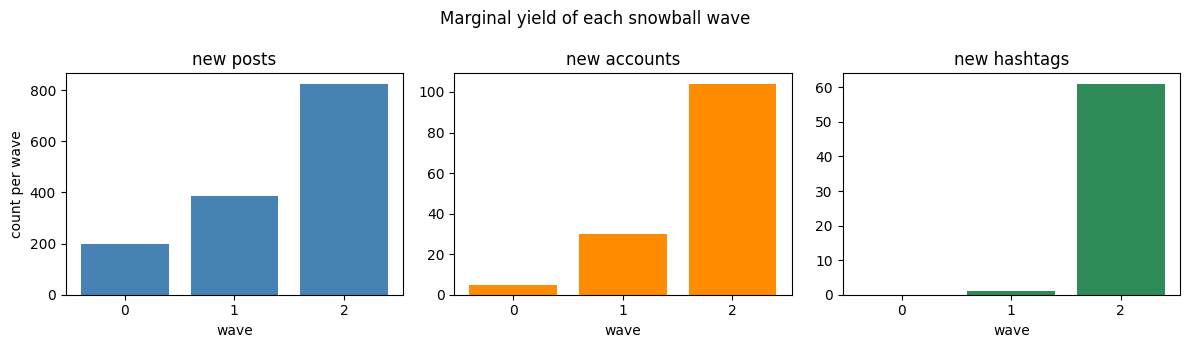

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True)

for ax, column, color in zip(axes,
                             ['new_posts', 'new_accounts', 'new_hashtags'],
                             ['steelblue', 'darkorange', 'seagreen']):
    ax.bar(wave_stats.index, wave_stats[column], color=color)
    ax.set_title(column.replace('_', ' '))
    ax.set_xlabel('wave')
    ax.set_xticks(wave_stats.index)

axes[0].set_ylabel('count per wave')
fig.suptitle('Marginal yield of each snowball wave')
fig.tight_layout()

How to read these curves: because each wave crawls *different* accounts, new posts stay high by construction — that panel mostly tracks how many accounts each wave crawled. The diagnostic panels are the **discovery** curves. If new accounts per wave keeps climbing, the social neighborhood is still opening up (typical: social networks expand multiplicatively, which is why uncapped snowballs explode). If new hashtags per wave shrinks, the *topical* vocabulary is closing — for a topic-focused corpus that is your saturation signal.

In practice you stop on whichever comes first: saturation in the quantity you care about, or your pre-registered budget (accounts, requests, or time). Either way, *write the rule down* — which is exactly what the metadata file in the next section is for.

## 6. Building the archive

Now we flatten everything into a **tidy** DataFrame — one row per post, one column per variable (Wickham 2014) — using `post_to_row` from `snowball.py`. We deduplicate by `uri`, keeping the earliest wave that found each post, parse the timestamp strings into real datetimes with [`pd.to_datetime`](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html), and sort chronologically with [`sort_values`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html).

We will save the archive as **Parquet**, a compressed, columnar file format that pandas reads and writes through the [PyArrow](https://arrow.apache.org/docs/python/parquet.html) engine. We prefer it to CSV here for one concrete reason: the list-valued columns (`langs`, `hashtags`, `mentions`, `links`) survive a round-trip through Parquet intact, whereas CSV would flatten them into strings you would have to re-parse.

In [18]:
rows, seen = [], set()
for wave, posts in wave_posts.items():
    for post in posts:
        if post.uri in seen:
            continue
        seen.add(post.uri)
        rows.append(post_to_row(post, wave=wave))

archive = pd.DataFrame(rows)
archive['created_at'] = pd.to_datetime(archive['created_at'], format='ISO8601',
                                       utc=True, errors='coerce')
archive = archive.sort_values('created_at').reset_index(drop=True)

print(archive.shape)
archive.head(3)

(1413, 15)


,uri,cid,author_did,author_handle,created_at,text,langs,is_reply,like_count,repost_count,reply_count,hashtags,mentions,links,wave
0,at://did:plc:3kf2k7zfamwpwjf5x5lazrpu/app.bsky...,bafyreicywnztf55xxiaywr4t3te6f37hcu4xt7exttamg...,did:plc:3kf2k7zfamwpwjf5x5lazrpu,jameshorncastle.bsky.social,2024-11-14 09:17:52.738000+00:00,🚨 Exclusive Moise Kean interview\n🟣 Already up...,[en],False,38,3,2,[],[],[https://www.nytimes.com/athletic/5919241/2024...,2
1,at://did:plc:jrin4u344pirosyfjo7qwvsx/app.bsky...,bafyreierr6ziequupucwust4ocboyv7shrhfrnspdsrcy...,did:plc:jrin4u344pirosyfjo7qwvsx,polballus.bsky.social,2024-11-19 20:45:00.927000+00:00,I had been wondering for days what sort of fun...,[ca],False,23,4,1,[],[did:plc:fc7x6ag6r5gjnrwazwimgfsc],[https://www.nytimes.com/athletic/5931613/2024...,2
2,at://did:plc:hmdj5mhly2rbpm2kqxzknstd/app.bsky...,bafyreichu2ngeke7avtzkzgkuq4gjpdqhdrcaducqmbql...,did:plc:hmdj5mhly2rbpm2kqxzknstd,charpur.bsky.social,2024-11-20 12:04:44.252000+00:00,Ruben Amorim has brought 5 members of coaching...,[en],False,50,5,1,[mufc],"[did:plc:fa7xejyd32fvuar5hpa2n2yi, did:plc:jeb...",[https://www.nytimes.com/athletic/5932085/2024...,2


### Saving the archive — and its provenance

A bare data file is not reproducible; six months from now, neither you nor a reviewer will remember how it was built. So alongside `archive.parquet` (written with [`DataFrame.to_parquet`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_parquet.html)) we save `archive_metadata.json` recording the seed, every cap and parameter, the accounts actually crawled, the per-wave yields, and the collection timestamp. Treat this file as the codebook for your sampling frame: anyone holding it can re-run the crawl and understand every boundary you drew.

In [19]:
from pathlib import Path

data_dir = Path('data')
data_dir.mkdir(exist_ok=True)

archive.to_parquet(data_dir / 'archive.parquet', index=False)

metadata = {
    'collected_at': COLLECTED_AT,
    'collection_method': 'snowball sample over mention and reply-parent edges',
    'seed_actor': SEED_ACTOR,
    'seed_did': seed_did,
    'parameters': {
        'wave0_max_posts': WAVE0_MAX_POSTS,
        'wave1_accounts': WAVE1_ACCOUNTS,
        'posts_per_account': POSTS_PER_ACCOUNT,
        'max_total_accounts': MAX_TOTAL_ACCOUNTS,
        'pause_seconds': PAUSE,
        'reposts_included': False,
        'replies_included': True,
    },
    'accounts_crawled': sorted(crawled),
    'wave_yields': wave_stats.reset_index().to_dict(orient='records'),
    'total_posts': int(len(archive)),
}

with open(data_dir / 'archive_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

for path in sorted(data_dir.iterdir()):
    print(f"{path}  ({path.stat().st_size / 1024:.0f} KB)")

data/archive.parquet  (335 KB)
data/archive_metadata.json  (1 KB)


### Proving the round-trip

Downstream notebooks should be able to start from the files alone. Reload the Parquet with [`pd.read_parquet`](https://pandas.pydata.org/docs/reference/api/pandas.read_parquet.html) and check that nothing was lost. One wrinkle to remember: Parquet returns the list-valued columns as NumPy arrays rather than Python lists — fine for analysis, just not identical types.

In [20]:
reloaded = pd.read_parquet(data_dir / 'archive.parquet')

assert len(reloaded) == len(archive)
assert (reloaded['uri'] == archive['uri']).all()
assert reloaded['created_at'].is_monotonic_increasing

print(f"Round-trip OK: {len(reloaded)} posts, "
      f"{reloaded['author_did'].nunique()} authors, "
      f"{reloaded['created_at'].min():%Y-%m-%d} to {reloaded['created_at'].max():%Y-%m-%d}")
print('langs column reloads as:', type(reloaded['langs'].iloc[0]).__name__)

Round-trip OK: 1413 posts, 15 authors, 2024-11-14 to 2026-06-10
langs column reloads as: ndarray


### Re-hydrating archived posts

Archives go stale in two ways: engagement counts keep moving after you collect, and posts get deleted. `get_posts` accepts up to 25 URIs and returns fresh views for the ones that still exist — making it both a refresh tool and a **deletion detector**. (We collected minutes ago, so expect little drift here; re-run this against a weeks-old archive and the differences become substantial. Honoring deletions when you share or re-publish data is an ethical obligation, not just hygiene.)

In [21]:
sample = reloaded.sample(10, random_state=42)

fresh = client.get_posts(uris=sample['uri'].tolist()).posts
fresh_likes = {post.uri: post.like_count for post in fresh}

comparison = sample[['author_handle', 'uri', 'like_count']].copy()
comparison['like_count_now'] = comparison['uri'].map(fresh_likes)
comparison['still_exists'] = comparison['like_count_now'].notna()

print(f"{len(fresh)} of {len(sample)} sampled posts still retrievable")
comparison[['author_handle', 'like_count', 'like_count_now', 'still_exists']]

10 of 10 sampled posts still retrievable


,author_handle,like_count,like_count_now,still_exists
812,theathleticfc.bsky.social,227,227,True
916,theathletic.com,9,9,True
339,meganferinga.bsky.social,21,21,True
192,charpur.bsky.social,6,6,True
203,charpur.bsky.social,0,0,True
778,adamcrafton.bsky.social,12,12,True
532,david-ornstein.bsky.social,46,46,True
67,charpur.bsky.social,8,8,True
993,nytopinion.nytimes.com,5,5,True
51,thomaslfriedman.bsky.social,12,12,True


In the comparison table, `still_exists` comes back `False` for any sampled post deleted since collection (its row is simply missing from the `get_posts` response), and the gap between `like_count` and `like_count_now` measures engagement drift. Minutes after collection both effects should be near zero — the point is the *procedure*, which becomes essential once an archive is weeks old and you owe deleted posts their deletion.

## 7. A first look at the archive

Before any serious analysis, basic descriptives tell us what the snowball actually scooped up — and they double as sanity checks on the collection itself. Three quick views: the hashtag vocabulary, the most-mentioned accounts, and how the corpus is distributed across authors.

First, hashtags. Because `hashtags` is a list-valued column, we call [`Series.explode`](https://pandas.pydata.org/docs/reference/api/pandas.Series.explode.html) to give every (post, hashtag) pair its own row, then [`value_counts`](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html) to tally them. The result is the archive's topical vocabulary at a glance.

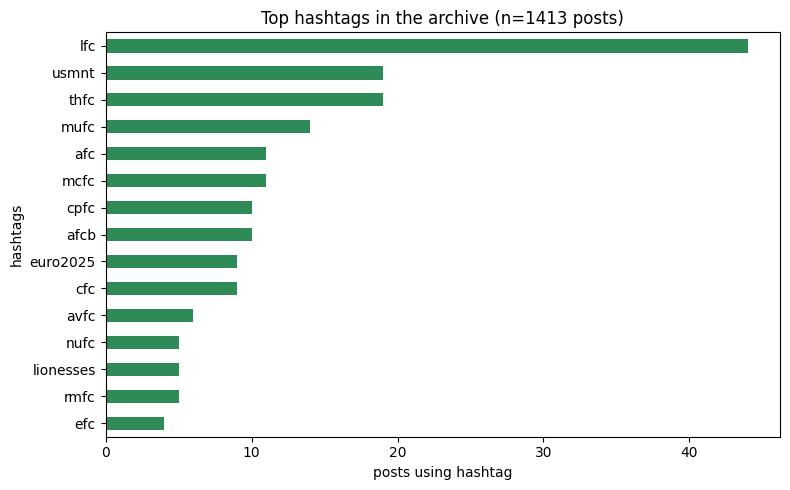

In [22]:
tag_counts = reloaded['hashtags'].explode().dropna().value_counts().head(15)

fig, ax = plt.subplots(figsize=(8, 5))
tag_counts.sort_values().plot.barh(ax=ax, color='seagreen')
ax.set_xlabel('posts using hashtag')
ax.set_title(f'Top hashtags in the archive (n={len(reloaded)} posts)')
fig.tight_layout()

Second, the most-mentioned accounts. The `mentions` column stores DIDs — stable but unreadable — so after the same explode-and-count pattern we resolve the top ten back to handles with `get_profile`, wrapped in `try`/`except` because mentioned accounts can be deleted or deactivated by the time you look them up. The resulting table is a rough who's-who of the conversations the snowball traversed.

In [23]:
mention_counts = reloaded['mentions'].explode().dropna().value_counts().head(10)

resolved = []
for did, n in mention_counts.items():
    try:
        handle = client.get_profile(actor=did).handle
    except Exception:
        handle = '(unresolvable)'
    resolved.append({'handle': handle, 'did': did, 'times_mentioned': n})
    time.sleep(PAUSE)

pd.DataFrame(resolved)

,handle,did,times_mentioned
0,theathleticfc.bsky.social,did:plc:fa7xejyd32fvuar5hpa2n2yi,274
1,theathletic.com,did:plc:b2kutgxqlltwc6lhs724cfwr,59
2,nytopinion.nytimes.com,did:plc:yllqcfu4oy424rlfpnzj32ka,14
3,tombogert.bsky.social,did:plc:ubbw452rsazc436oq5xnagp7,11
4,meganferinga.bsky.social,did:plc:3dhjfhx2bnydk4akjrcyasok,9
5,henrybushnell.bsky.social,did:plc:6j654bfrsgzqxto4x74c466d,9
6,david-ornstein.bsky.social,did:plc:j62szermx6ods7lp3xqyembx,8
7,paultenorio.bsky.social,did:plc:56ojnkucm6ylfmz3h3otztfh,6
8,charpur.bsky.social,did:plc:hmdj5mhly2rbpm2kqxzknstd,5
9,adamcrafton.bsky.social,did:plc:mpa43z7u2yc5wlajvghcio3q,5


Third, the shape of the corpus itself: how many posts each crawled author contributed. We use [`groupby`](https://pandas.pydata.org/docs/user_guide/groupby.html) with named aggregations to count posts and replies and take median likes per author. Watch for imbalance here — if one prolific account contributes a third of the archive, any "corpus-level" finding may really be a finding about that one account.

,posts,replies,median_likes
author_handle,,,
nytimes.com,200,0,55.0
david-ornstein.bsky.social,100,0,50.5
adamcrafton.bsky.social,100,31,11.0
meganferinga.bsky.social,100,25,7.0
jacklang.bsky.social,100,48,1.5
charpur.bsky.social,100,10,3.5
henrybushnell.bsky.social,100,22,11.0
paultenorio.bsky.social,100,23,12.0
nytopinion.nytimes.com,100,0,3.0


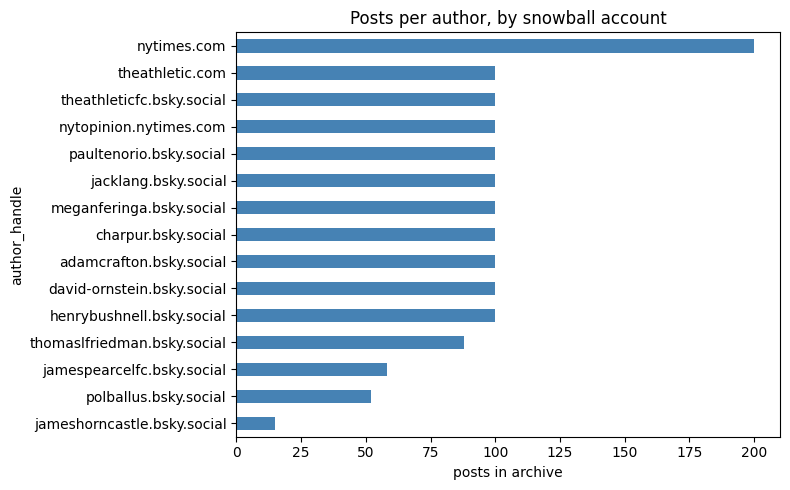

In [24]:
by_author = (reloaded
             .groupby('author_handle')
             .agg(posts=('uri', 'size'),
                  replies=('is_reply', 'sum'),
                  median_likes=('like_count', 'median'))
             .sort_values('posts'))

fig, ax = plt.subplots(figsize=(8, 5))
by_author['posts'].plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('posts in archive')
ax.set_title('Posts per author, by snowball account')
fig.tight_layout()

by_author.sort_values('posts', ascending=False)

## 8. Research design: what kind of sample is this?

The descriptives above already show the sample's construction leaking into its content: the top hashtags and most-mentioned accounts reflect whom we chose to crawl at least as much as any underlying conversation. A snowball sample is *defensible*, not *representative*. Before treating an archive like this as "the conversation", name its biases:

* **Seed dependence.** Everything is anchored to one account's social neighborhood. A different seed yields a different corpus; serious designs use multiple, deliberately diverse seeds and report sensitivity to seed choice.
* **Popularity bias.** Ranking the frontier by engagement count systematically recruits visible, frequently-mentioned accounts. Quiet participants in the same conversations are under-sampled — the same dynamic that makes hashtag samples over-represent the loudest voices (Tufekci 2014).
* **Homophily.** People engage with similar others, so waves stay inside communities resembling the seed and cross community boundaries slowly. Two waves from an academic seed yield an academic corpus, whatever the topic.
* **Activity bias.** "Most recent N posts" covers different time windows for different accounts: a prolific poster's 100 posts span days, a quiet account's span years. Time-bounded designs should filter on `created_at` instead of post counts.
* **Index and survivorship effects.** Search-based frames (Section 1) inherit the index's gaps; snowball frames inherit deletion effects at collection time. Both differ from real-time collection (Part 10).

None of these are fatal — every sampling frame has biases. What separates defensible from indefensible corpora is **documentation**: the seeds, the edge definition, the caps, the stopping rule, and the collection date, all written down before reviewers ask. That is the function of `archive_metadata.json`, and it is the discipline Bruns & Burgess (2011) urged when they showed that a "hashtag public" is an analytic construction, not a natural object. For a broad, readable catalogue of how these biases arise at every stage of the social-data pipeline, see Olteanu et al. (2019).

## Ethics and limitations

**Third parties never opted in.** This is the central ethical fact of snowball designs: the seed account consented to being this series' example, but the accounts pulled in by mentions and replies did not. Our archive contains their posts solely because someone else engaged them. Minimize accordingly — collect only the fields your question needs, prefer aggregates (as in Section 7) over individual rows when reporting, and paraphrase rather than quote: verbatim post text is trivially re-identifiable via search even with handles removed (the lesson of Zimmer 2010).

**Honor deletion and opt-out signals.** Users delete posts and accounts, and some set the `!no-unauthenticated` label on their profiles. Record collection dates (we did), re-check with `get_posts` before re-publishing (Section 6), and drop records that have disappeared.

**Bots and automated accounts** ride along in mention-based frontiers — inspect your crawl list before interpreting the corpus as human conversation.

**Public is not consent, and exempt is not automatic.** Bluesky users mostly have not read the protocol docs and may not expect their posts in a dataset (Fiesler & Proferes 2018). Consult your IRB and the AoIR Internet Research Ethics guidelines (franzke et al. 2020, [PDF](https://aoir.org/reports/ethics3.pdf)) before turning a tutorial pipeline into a study.

**Limitations of this archive.** It is demonstration-scale (15 accounts, ~1,500 posts) and account-anchored rather than topic-anchored; with authentication, you would combine search (Section 1) with snowballing to triangulate a topical frame. Bluesky's user base skews toward early adopters and Twitter migrants, so prevalence claims do not generalize beyond the platform — the model-organism caution (Tufekci 2014) applies in full.

## Exercises

These extend the notebook roughly in order of ambition. For all of them, keep the politeness conventions (pauses between requests, explicit caps) and write your design choices down the way `archive_metadata.json` does.

1. **Swap the seed.** Change `SEED_ACTOR` to a public-institution account such as `bsky.app` (the official Bluesky account) and re-run Sections 4–7. Which top hashtags and most-mentioned accounts change, and which crawl parameters did you have to adjust to stay under budget?
2. **Go one wave deeper.** Add a wave 3: rank the accounts wave 2 engaged (excluding everyone already crawled), raise `MAX_TOTAL_ACCOUNTS` modestly (say, to 25), and extend the saturation table and bar charts. Do the discovery curves for new accounts and new hashtags bend downward, or is the frontier still expanding?
3. **Change the edge definition.** Modify the frontier-ranking step to use *mentions only*, then *reply parents only* (both are one-line changes around `count_engaged_accounts`'s inputs — or write two small variants of it). How much do the two top-8 frontiers overlap with each other and with the original?
4. **Time-bound wave 0.** Replace "the most recent 200 posts" with "every original post since a fixed date" by filtering on `record.created_at` inside the collection loop. Section 8 explains why this matters: fixed-window designs make accounts comparable in *time* rather than in *post count*.
5. **Compare two seeds' archives.** Build a second archive from a different seed (Exercise 1), save it under a different filename, and quantify how much the two corpora share: the [Jaccard similarity](https://en.wikipedia.org/wiki/Jaccard_index) of their author-DID sets and of their hashtag vocabularies. Python's `set` operations on the exploded columns are all you need.
6. **Hashtag co-occurrence network.** For every post with two or more hashtags, generate the tag pairs with [`itertools.combinations`](https://docs.python.org/3/library/itertools.html#itertools.combinations), count pairs with a `Counter`, and inspect the top 20 as an edge-list DataFrame. If you want a preview of Part 03, load the edge list into [NetworkX](https://networkx.org/documentation/stable/) and draw the network of tags that travel together.

## Research project ideas

**1. Who do hashtags miss? Auditing a hashtag public on Bluesky.** Bruns & Burgess (2011) framed hashtags as "ad hoc publics," and Tufekci (2014) warned that hashtag samples capture only the most performative participants. *Question:* who participates in a conversation without ever tagging it? *Data:* pick an active, well-established hashtag (an academic community tag or a recurring event tag), collect an authenticated `searchPosts` archive for it over a fixed window, and in parallel snowball from 3–5 visibly active participants over the same window. *Method:* compare the two frames — identify accounts in the snowball corpus whose posts discuss the topic (keyword match in `text`) but never carry the hashtag, and compare their posting and engagement profiles to the hashtag users'. *Expected challenge:* deciding a post is "about the topic" without the tag requires a keyword dictionary or a simple classifier, and you must validate it by hand-coding a sample.

**2. Seed sensitivity: how fragile are snowball corpora?** Morstatter et al. (2013) showed that conclusions can hinge on how a sample was drawn; Olteanu et al. (2019) catalogue acquisition bias as a pipeline-wide problem. *Question:* how much does a two-wave snowball corpus depend on its seed? *Data:* run the identical pipeline (same caps, edge definition, and date) from five or more seeds chosen from visibly different communities. *Method:* compute pairwise Jaccard overlap of the corpora's account sets and hashtag vocabularies, then test which summary statistics (reply share, median likes, top-tag concentration) are stable across seeds and which are seed-driven; report the spread as a sensitivity analysis. *Expected challenge:* budget — five crawls multiply your request count, so you will need the rate-limit discipline from Part 01 and tight per-account caps.

**3. The half-life of a post archive.** Search indexes and archives inherit survivorship bias (Morstatter et al. 2013), and deletion is also an ethical signal you are obliged to honor (Zimmer 2010; Fiesler & Proferes 2018). *Question:* how fast does a Bluesky archive decay through deletion and engagement drift, and is the decay selective? *Data:* one snowball archive collected today, re-hydrated weekly with `get_posts` (Section 6's procedure) for 8–12 weeks, storing only per-URI status and counts at each check. *Method:* estimate a survival curve for post deletion, compare deleted versus surviving posts on collection-time features (engagement, reply status, hashtags), and plot engagement-drift trajectories. *Expected challenge:* the ethics are the design — once a post is deleted you must drop its content and retain only the fact and date of deletion, so pre-register exactly which minimal fields each weekly check keeps.

## References

### Scholarship

* Bruns, A., & Burgess, J. (2011). The use of Twitter hashtags in the formation of ad hoc publics. *Proceedings of the 6th European Consortium for Political Research (ECPR) General Conference*.
* Fiesler, C., & Proferes, N. (2018). "Participant" perceptions of Twitter research ethics. *Social Media + Society*, 4(1).
* franzke, a. s., Bechmann, A., Zimmer, M., Ess, C., & the Association of Internet Researchers (2020). *Internet Research: Ethical Guidelines 3.0*. [PDF](https://aoir.org/reports/ethics3.pdf)
* Goodman, L. A. (1961). Snowball sampling. *Annals of Mathematical Statistics*, 32(1), 148–170.
* Morstatter, F., Pfeffer, J., Liu, H., & Carley, K. M. (2013). Is the sample good enough? Comparing data from Twitter's Streaming API with Twitter's firehose. *Proceedings of ICWSM*. [arXiv](https://arxiv.org/abs/1306.5204)
* Olteanu, A., Castillo, C., Diaz, F., & Kıcıman, E. (2019). Social data: Biases, methodological pitfalls, and ethical boundaries. *Frontiers in Big Data*, 2, 13. [Open access](https://www.frontiersin.org/articles/10.3389/fdata.2019.00013/full)
* Rafail, P. (2018). Nonprobability sampling and Twitter: Strategies for semibounded and bounded populations. *Social Science Computer Review*, 36(2), 195–211.
* Tufekci, Z. (2014). Big questions for social media big data: Representativeness, validity and other methodological pitfalls. *Proceedings of ICWSM*. [arXiv](https://arxiv.org/abs/1403.7400)
* Wickham, H. (2014). Tidy data. *Journal of Statistical Software*, 59(10). [Open access](https://www.jstatsoft.org/article/view/v059i10)
* Zimmer, M. (2010). "But the data is already public": On the ethics of research in Facebook. *Ethics and Information Technology*, 12(4), 313–325.

### Documentation

* [`app.bsky.feed.searchPosts`](https://docs.bsky.app/docs/api/app-bsky-feed-search-posts), [`app.bsky.feed.getPosts`](https://docs.bsky.app/docs/api/app-bsky-feed-get-posts), and [`app.bsky.feed.getAuthorFeed`](https://docs.bsky.app/docs/api/app-bsky-feed-get-author-feed) — the endpoints this notebook uses
* [Post rich text and facets](https://docs.bsky.app/docs/advanced-guides/post-richtext) — the byte-offset facet model behind Section 2
* AT Protocol specifications: the [`at://` URI scheme](https://atproto.com/specs/at-uri-scheme), [DIDs](https://atproto.com/specs/did), [record keys](https://atproto.com/specs/record-key), and the [lexicon guide](https://atproto.com/guides/lexicon)
* [atproto Python SDK](https://atproto.blue) — the client library wrapped by `bsky_client.py`
* pandas: [`to_datetime`](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html), [`explode`](https://pandas.pydata.org/docs/reference/api/pandas.Series.explode.html), [`value_counts`](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html), [`groupby`](https://pandas.pydata.org/docs/user_guide/groupby.html), [`to_parquet`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_parquet.html) / [`read_parquet`](https://pandas.pydata.org/docs/reference/api/pandas.read_parquet.html)
* [PyArrow Parquet](https://arrow.apache.org/docs/python/parquet.html) — the engine behind the archive file